In [69]:
import sys

sys.path.insert(0, "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr")
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.metrics.phone_recognition import PhoneRecognitionEvaluator
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_dataset_predictions,
    build_utt_dataframe,
    audio_duration,
    annotate_lang_meta,
    load_voxangeles_lang_meta,
    VA_AUDIO_PATTERN,
)

sns.set_theme(style="whitegrid", font_scale=1.15)

# ── Define the two models to compare ─────────────────────────────────────────
MODEL_A = "xeus_multiaccent.selfctc_l4_8_12.bs240.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000"

MODEL_B = "ebranch.selfctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000"

evaluator = PhoneRecognitionEvaluator(normalize_ipa=True)

OUT_DIR = Path(
    "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz"
)
OUT_DIR.mkdir(exist_ok=True)

FORCE_RECOMPUTE = False  # set True to ignore cached CSVs and recompute

In [70]:
# ── Reload utils (run after editing error_analysis_utils.py) ─────────────────
import importlib
import src.recipe.phone_recognition.local.error_analysis_utils as _eau

importlib.reload(_eau)
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_dataset_predictions,
    build_utt_dataframe,
    audio_duration,
    annotate_lang_meta,
    load_voxangeles_lang_meta,
    VA_AUDIO_PATTERN,
)

print("error_analysis_utils reloaded.")

error_analysis_utils reloaded.


In [71]:
# ── Load VoxAngeles predictions for both models ───────────────────────────────
a_name = "PhoneticXeus"
b_name = "E-BranchFormer"

_CSV = OUT_DIR / "cache_vox_per_utt.csv"
if not FORCE_RECOMPUTE and _CSV.exists():
    print(f"Loading cached per-utterance metrics from {_CSV}")
    df_all = pd.read_csv(_CSV)
    df_a = df_all[df_all.model == a_name].copy()
    df_b = df_all[df_all.model == b_name].copy()
else:
    print("=== voxangeles ===")
    va_preds = load_dataset_predictions("voxangeles", models=[MODEL_A, MODEL_B])

    va_audio = None
    preds_a = {MODEL_A: va_preds[MODEL_A]}
    preds_b = {MODEL_B: va_preds[MODEL_B]}

    print("\nComputing per-utterance metrics for MODEL_A ...")
    df_a = build_utt_dataframe(preds_a, evaluator, audio_fn=va_audio)
    df_a["model"] = a_name

    print("Computing per-utterance metrics for MODEL_B ...")
    df_b = build_utt_dataframe(preds_b, evaluator, audio_fn=va_audio)
    df_b["model"] = b_name

    df_all = pd.concat([df_a, df_b], ignore_index=True)
    df_all.to_csv(_CSV, index=False)
    print(f"Cached → {_CSV}")

print(f'\nMODEL_A: {len(df_a)} utts, mean FER={df_a["fer"].mean():.2f}%')
print(f'MODEL_B: {len(df_b)} utts, mean FER={df_b["fer"].mean():.2f}%')
df_all.head()

Loading cached per-utterance metrics from /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/cache_vox_per_utt.csv

MODEL_A: 5445 utts, mean FER=14.83%
MODEL_B: 5445 utts, mean FER=20.64%


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration,model
0,lit-002-067-28,lit,lit,iːstʲɾʲɪʒʲaɪ,estiriʒɑejestiriʒɑs,11.333333,129.947917,10.395833,225.0,8,NaN,PhoneticXeus
1,lit-002-069-29,lit,lit,iispuːdʲɪs,ispudis,1.125000,13.020833,1.041667,50.0,8,NaN,PhoneticXeus
2,lit-002-070-30,lit,lit,dʲeːka,dieka,1.083333,25.000000,1.000000,75.0,4,NaN,PhoneticXeus
3,lit-002-111-31,lit,lit,tʊɾʲtʲɛ,turta,0.291667,5.416667,0.270833,80.0,5,NaN,PhoneticXeus
4,lit-002-112-32,lit,lit,tʊɾtas,torrtas,1.083333,15.972222,0.958333,50.0,6,NaN,PhoneticXeus


In [72]:
# ── Annotate with language family and macroarea ───────────────────────────────
lang_meta = load_voxangeles_lang_meta()
df_a = annotate_lang_meta(df_a, lang_meta)
df_b = annotate_lang_meta(df_b, lang_meta)
df_all = annotate_lang_meta(df_all, lang_meta)

print(
    f"Coverage: {df_a['family'].notna().sum()}/{len(df_a)} utts have family annotation"
)
print(f"Families : {sorted(df_a['family'].dropna().unique())}")
print(f"Macroareas: {sorted(df_a['macroarea'].dropna().unique())}")
df_all[["langcode", "family", "macroarea"]].drop_duplicates().sort_values("langcode")

Coverage: 5399/5445 utts have family annotation
Families : ['Abkhaz-Adyge', 'Afro-Asiatic', 'Athabaskan-Eyak-Tlingit', 'Atlantic-Congo', 'Austroasiatic', 'Austronesian', 'Central Sudanic', 'Dravidian', 'Ijoid', 'Indo-European', 'Kakua-Nukak', 'Kru', 'Mande', 'Nakh-Daghestanian', 'Nuclear Torricelli', 'Salishan', 'Sino-Tibetan', 'Siouan', 'Turkic', 'Uralic']
Macroareas: ['Africa', 'Eurasia', 'North America', 'Papunesia', 'South America']


,langcode,family,macroarea
1387,abk,Abkhaz-Adyge,Eurasia
1441,ace,Austronesian,Papunesia
1480,ady,Abkhaz-Adyge,Eurasia
1601,aeb,Afro-Asiatic,Africa
1643,afn,Ijoid,Africa
...,...,...,...
1124,tsw,Atlantic-Congo,Africa
1150,tzm,Afro-Asiatic,Africa
1190,wuu,Sino-Tibetan,Eurasia
1261,yue,Sino-Tibetan,Eurasia


In [ ]:
df_a.groupby("langname").agg({"fer": ["mean", "count"]}).sort_values(
    ("fer", "mean"), ascending=False
).head(10)

fer      
               mean count
langname                 
led       44.384058    23
wuu       40.087050    71
cbv       36.261141    63
col       34.095978    46
ady       28.118571   121
ewe       25.667032    38
hak       25.207589    40
cji       24.828756    44
bsq       23.541667    24
brv       23.359568    45

In [ ]:
# read audio and display with reference and prediction of 20 random utterances each from led, wuu, and cbv

,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration,model,family,macroarea
0,lit-002-067-28,lit,lit,iːstʲɾʲɪʒʲaɪ,estiriʒɑejestiriʒɑs,11.333333,129.947917,10.395833,225.000000,8,NaN,PhoneticXeus,Indo-European,Eurasia
1,lit-002-069-29,lit,lit,iispuːdʲɪs,ispudis,1.125000,13.020833,1.041667,50.000000,8,NaN,PhoneticXeus,Indo-European,Eurasia
2,lit-002-070-30,lit,lit,dʲeːka,dieka,1.083333,25.000000,1.000000,75.000000,4,NaN,PhoneticXeus,Indo-European,Eurasia
3,lit-002-111-31,lit,lit,tʊɾʲtʲɛ,turta,0.291667,5.416667,0.270833,80.000000,5,NaN,PhoneticXeus,Indo-European,Eurasia
4,lit-002-112-32,lit,lit,tʊɾtas,torrtas,1.083333,15.972222,0.958333,50.000000,6,NaN,PhoneticXeus,Indo-European,Eurasia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5440,lgq-001-022-19,lgq,lgq,oʃibie,baʃibie,1.083333,16.666667,1.000000,33.333333,6,NaN,PhoneticXeus,Atlantic-Congo,Africa
5441,lgq-001-023-20,lgq,lgq,uxe,uxe,0.000000,0.000000,0.000000,0.000000,3,NaN,PhoneticXeus,Atlantic-Congo,Africa
5442,lgq-001-024-21,lgq,lgq,uhɛ̃,uhe,0.083333,2.777778,0.083333,33.333333,3,NaN,PhoneticXeus,Atlantic-Congo,Africa
5443,lgq-001-025-22,lgq,lgq,ɔʒa,ɔʒa,0.000000,0.000000,0.000000,0.000000,3,NaN,PhoneticXeus,Atlantic-Congo,Africa


In [75]:
fer_comparison = df_all.groupby(["model", "family"])["fer"].mean()
fer_comparison = (
    fer_comparison.reset_index()
    .pivot(index="family", columns="model", values="fer")
    .reset_index()
)
fer_comparison

model,family,E-BranchFormer,PhoneticXeus
0,Abkhaz-Adyge,35.513072,25.794435
1,Afro-Asiatic,17.481354,12.353271
2,Athabaskan-Eyak-Tlingit,21.387662,18.874901
3,Atlantic-Congo,18.912361,12.545281
4,Austroasiatic,27.711137,18.164036
5,Austronesian,17.788536,11.011311
6,Central Sudanic,38.315217,44.384058
7,Dravidian,20.463861,14.938705
8,Ijoid,17.376352,10.491743
9,Indo-European,17.472718,12.352518


/tmp/ipykernel_1720405/2520308536.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)


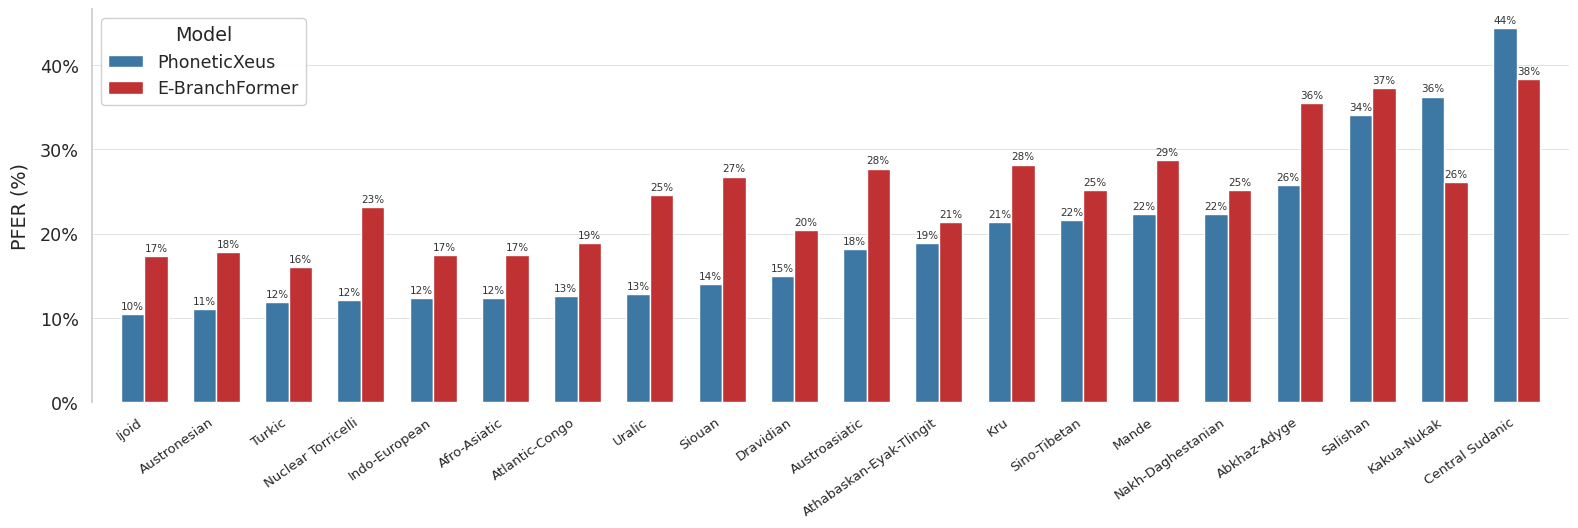

Saved → /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/vox_family.pdf


In [29]:
PALETTE = {a_name: "#2c7bb6", b_name: "#d7191c"}

# ── melt to long form, sort by MODEL_A FER ascending ─────────────────────────
_CSV = OUT_DIR / "cache_vox_family_fer.csv"
if not FORCE_RECOMPUTE and _CSV.exists():
    plot_df = pd.read_csv(_CSV)
else:
    plot_df = fer_comparison.sort_values(a_name).melt(
        id_vars="family",
        value_vars=[a_name, b_name],
        var_name="Model",
        value_name="FER (%)",
    )
    plot_df.to_csv(_CSV, index=False)

fig, ax = plt.subplots(figsize=(16, 5.5))

sns.barplot(
    data=plot_df,
    x="family",
    y="FER (%)",
    hue="Model",
    palette=PALETTE,
    width=0.65,
    ax=ax,
)

# value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", fontsize=7.5, padding=2, color="#333333")

ax.yaxis.grid(True, color="#dddddd", linewidth=0.6, linestyle="-")
ax.set_axisbelow(True)

# ax.set_title("PFER by Language Family", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("PFER (%)", labelpad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
ax.legend(title="Model", frameon=True, loc="upper left", framealpha=0.9)
ax.margins(x=0.02)
sns.despine(bottom=True)
plt.tight_layout()
plt.savefig(OUT_DIR / "vox_family.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'vox_family.pdf'}")

In [30]:
lang_fer_agg = (
    df_all.groupby(["model", "langname"])["fer"]
    .agg(mean="mean", std="std")
    .reset_index()
)

mean_pivot = lang_fer_agg.pivot(
    index="langname", columns="model", values="mean"
).reset_index()
std_pivot = lang_fer_agg.pivot(
    index="langname", columns="model", values="std"
).reset_index()
std_pivot = std_pivot.rename(columns={a_name: f"{a_name}_std", b_name: f"{b_name}_std"})

lang_fer_comparison = mean_pivot.merge(std_pivot, on="langname")
lang_fer_comparison.columns.name = None
lang_fer_comparison

,langname,E-BranchFormer,PhoneticXeus,E-BranchFormer_std,PhoneticXeus_std
0,abk,44.096579,20.586649,73.375066,13.979221
1,ace,23.976012,11.810897,34.833909,13.484772
2,ady,31.682415,28.118571,22.543104,22.171447
3,aeb,21.343852,12.622000,17.331766,12.047973
4,afn,17.376352,10.491743,35.071641,17.072578
...,...,...,...,...,...
89,sbc,20.495744,16.145905,15.051381,13.233299
90,tsw,15.107601,14.200435,15.841764,20.040854
91,tzm,20.101687,14.893105,21.177989,21.182090
92,wuu,41.671557,40.087050,50.630140,30.507707


In [31]:
lang_fer_comparison.sort_values(a_name, ascending=False).head(20)

,langname,E-BranchFormer,PhoneticXeus,E-BranchFormer_std,PhoneticXeus_std
73,led,38.315217,44.384058,19.535717,34.063295
92,wuu,41.671557,40.087050,50.630140,30.507707
24,cbv,26.151843,36.261141,15.500613,28.916746
28,col,37.285567,34.095978,15.998680,19.052211
2,ady,31.682415,28.118571,22.543104,22.171447
38,ewe,28.710709,25.667032,17.871401,23.324088
46,hak,24.571925,25.207589,24.531741,29.592886
27,cji,29.498895,24.828756,32.443906,23.981450
22,bsq,27.472512,23.541667,20.230867,16.596205
21,brv,33.643519,23.359568,29.087652,13.655057


In [88]:
# ── Audio spot-check: 20 random utterances each for led, wuu, cbv ─────────────
import os
from IPython.display import Audio, display, HTML

SPOT_LANGS = ["led", "wuu", "cbv"]
N_SAMPLE = 20
VA_AUDIO_PAT = (
    "/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/test_voxangeles"
    "/recording/{langcode}/{utt_id}.wav"
)

for lang in SPOT_LANGS:
    sub = df_a[df_a.langcode == lang]
    sample = sub.sample(min(N_SAMPLE, len(sub)), random_state=42)
    lname = sample.iloc[0]["langname"] if len(sample) else lang

    display(HTML(f"<h3>{lname} ({lang}) &mdash; {len(sample)} utterances shown</h3>"))

    for _, row in sample.iterrows():
        wav = VA_AUDIO_PAT.format(langcode=lang, utt_id=row.utt_id)
        display(
            HTML(
                f"<b>{row.utt_id}</b> &emsp; PER={row.per:.1f}% &nbsp; PFER={row.pfer:.1f}<br>"
                f"<tt><b>REF :</b> {row.reference}</tt><br>"
                f"<tt><b>PRED:</b> {row.predicted}</tt>"
            )
        )
        if os.path.exists(wav):
            display(Audio(filename=wav))  # reads only this file, on demand
            # print length in milliseconds
            duration_ms = audio_duration(row.utt_id, pattern=VA_AUDIO_PAT) * 1000
            display(HTML(f"<i style='color:gray'>duration: {duration_ms:.0f} ms</i>"))
        else:
            display(HTML("<i style='color:gray'>audio not found</i>"))

    display(HTML("<hr>"))

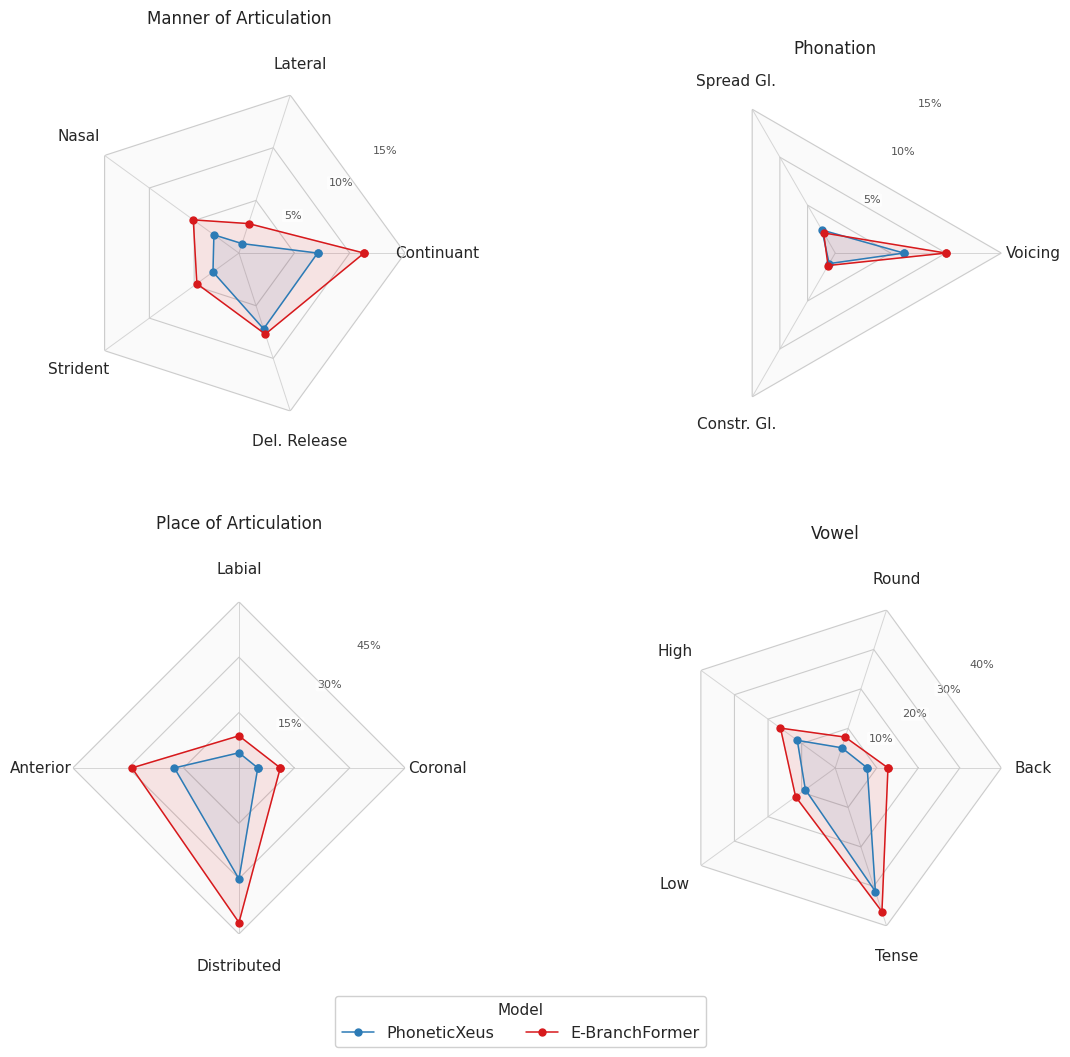

Saved → /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/vox_spider.pdf


In [60]:
from src.recipe.phone_recognition.local.error_analysis_utils import (
    df_to_entries,
    analyze_feature_errors,
)

FEAT_DISPLAY = {
    "syl": "Syllabic",
    "son": "Sonorant",
    "cons": "Consonantal",
    "cont": "Continuant",
    "delrel": "Del. Release",
    "lat": "Lateral",
    "nas": "Nasal",
    "strid": "Strident",
    "voi": "Voicing",
    "sg": "Spread Gl.",
    "cg": "Constr. Gl.",
    "ant": "Anterior",
    "cor": "Coronal",
    "distr": "Distributed",
    "lab": "Labial",
    "hi": "High",
    "lo": "Low",
    "back": "Back",
    "round": "Round",
    "tense": "Tense",
    "long": "Long",
}

FEATURE_TYPES = {
    "syl": "Major class",
    "son": "Major class",
    "cons": "Major class",
    "cont": "Manner of Articulation",
    "delrel": "Manner of Articulation",
    "lat": "Manner of Articulation",
    "nas": "Manner of Articulation",
    "strid": "Manner of Articulation",
    "voi": "Phonation",
    "sg": "Phonation",
    "cg": "Phonation",
    "ant": "Place of Articulation",
    "cor": "Place of Articulation",
    "distr": "Place of Articulation",
    "lab": "Place of Articulation",
    "hi": "Vowel",
    "lo": "Vowel",
    "back": "Vowel",
    "round": "Vowel",
    "tense": "Vowel",
    "long": "Quantity",
}

# ── Compute per-feature FER ───────────────────────────────────────────────────
_CSV = OUT_DIR / "cache_vox_feat_errors.csv"
if not FORCE_RECOMPUTE and _CSV.exists():
    feat_df = pd.read_csv(_CSV)
    feat_a = (
        feat_df[feat_df.model == a_name]
        .set_index("feature")[["fer", "errors", "total"]]
        .to_dict("index")
    )
    feat_b = (
        feat_df[feat_df.model == b_name]
        .set_index("feature")[["fer", "errors", "total"]]
        .to_dict("index")
    )
else:
    print("Computing feature errors for", a_name, "...")
    feat_a = analyze_feature_errors(df_to_entries(df_a))["per_feature"]
    print("Computing feature errors for", b_name, "...")
    feat_b = analyze_feature_errors(df_to_entries(df_b))["per_feature"]

    feat_df = pd.DataFrame(
        [{"model": a_name, "feature": f, **s} for f, s in feat_a.items()]
        + [{"model": b_name, "feature": f, **s} for f, s in feat_b.items()]
    )
    feat_df.to_csv(_CSV, index=False)
    print(f"Cached → {_CSV}")

# ── 4 spider charts, one per articulatory feature group ───────────────────────
# "Major class" and "Quantity" are excluded: too few/uninformative axes.
TYPE_ORDER = ["Manner of Articulation", "Phonation", "Place of Articulation", "Vowel"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11),
    subplot_kw=dict(polar=True),
    gridspec_kw={"hspace": 0.55, "wspace": 0.45},
)
axes_flat = axes.flatten()

for ax, ftype in zip(axes_flat, TYPE_ORDER):
    features = [
        f
        for f, t in FEATURE_TYPES.items()
        if t == ftype and f in feat_a and feat_a[f]["total"] > 0
    ]
    features = sorted(features, key=lambda f: -feat_a[f]["total"])

    labels = [FEAT_DISPLAY.get(f, f) for f in features]
    vals_a_grp = [feat_a[f]["fer"] * 100 for f in features]
    vals_b_grp = [feat_b[f]["fer"] * 100 for f in features]

    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    max_val = max(max(vals_a_grp), max(vals_b_grp))
    ylim = (int(max_val / 5) + 1) * 5
    ax.set_ylim(0, ylim)

    # ── polygonal grid (N-gon rings instead of circles) ──────────────────
    ax.yaxis.grid(False)  # no circles
    ax.xaxis.grid(True, color="#cccccc", linewidth=0.7, alpha=0.8)  # keep spokes
    ax.spines["polar"].set_visible(False)  # hide outer circle
    # light polygon fill for the chart area
    ax.fill(angles[:-1], [ylim] * N, color="#f5f5f5", alpha=0.45, zorder=0)
    # draw one polygon per ring level
    step = max(5, (ylim // 3 // 5) * 5)
    yticks = list(range(step, ylim + 1, step))
    for ring_r in yticks:
        ax.plot(
            angles, [ring_r] * len(angles), color="#cccccc", linewidth=0.8, zorder=1
        )

    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.tick_params(axis="y", labelsize=8, labelcolor="#555555")
    # place radial labels in the gap between the first two spokes
    ax.set_rlabel_position(180 / N)
    for txt in ax.yaxis.get_ticklabels():
        txt.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))

    for vals, name, color in [
        (vals_a_grp, a_name, PALETTE[a_name]),
        (vals_b_grp, b_name, PALETTE[b_name]),
    ]:
        v = vals + vals[:1]
        ax.plot(
            angles,
            v,
            "o-",
            linewidth=1.1,
            color=color,
            label=name,
            markersize=5.0,
            zorder=3,
        )
        ax.fill(angles, v, alpha=0.10, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.tick_params(axis="x", pad=10)
    ax.set_title(ftype, fontsize=12, pad=24, color="#222222")

# Single shared legend below the 2×2 grid
handles, leg_labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    leg_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
    frameon=True,
    framealpha=0.92,
    fontsize=11.5,
    title="Model",
    title_fontsize=11,
    handlelength=2,
)

plt.savefig(OUT_DIR / "vox_spider.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'vox_spider.pdf'}")

In [64]:
# ── Load GMUAccent predictions for both models ────────────────────────────────
_CSV = OUT_DIR / "cache_gmu_per_utt.csv"
if not FORCE_RECOMPUTE and _CSV.exists():
    print(f"Loading cached per-utterance metrics from {_CSV}")
    df_gmu_all = pd.read_csv(_CSV)
    df_gmu_a = df_gmu_all[df_gmu_all.model == a_name].copy()
    df_gmu_b = df_gmu_all[df_gmu_all.model == b_name].copy()
else:
    print("=== gmuaccent ===")
    gmu_preds = load_dataset_predictions("gmuaccent", models=[MODEL_A, MODEL_B])

    gmu_preds_a = {MODEL_A: gmu_preds[MODEL_A]}
    gmu_preds_b = {MODEL_B: gmu_preds[MODEL_B]}

    print("\nComputing per-utterance metrics for MODEL_A ...")
    df_gmu_a = build_utt_dataframe(gmu_preds_a, evaluator, audio_fn=None)
    df_gmu_a["model"] = a_name

    print("Computing per-utterance metrics for MODEL_B ...")
    df_gmu_b = build_utt_dataframe(gmu_preds_b, evaluator, audio_fn=None)
    df_gmu_b["model"] = b_name

    df_gmu_all = pd.concat([df_gmu_a, df_gmu_b], ignore_index=True)
    df_gmu_all.to_csv(_CSV, index=False)
    print(f"Cached → {_CSV}")

print(f'\nMODEL_A: {len(df_gmu_a)} utts, mean FER={df_gmu_a["fer"].mean():.2f}%')
print(f'MODEL_B: {len(df_gmu_b)} utts, mean FER={df_gmu_b["fer"].mean():.2f}%')
df_gmu_all.head()

Loading cached per-utterance metrics from /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/cache_gmu_per_utt.csv

MODEL_A: 1242 utts, mean FER=8.49%
MODEL_B: 1242 utts, mean FER=10.81%


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration,model
0,english151,english,english,pliːskʰɑlˠstɛləæskɚɾəbɹɪ̃ŋðiːz̥θɪ̃ŋzwɪθhɚfɹʌ̃m...,pʰlizkʰɔlstɛləæskhə˞tʰupɹɪ̃ŋðizθɪ̃ŋzwɪðhə˞fɹʌm...,18.583333,7.968510,17.291667,29.953917,217,NaN,PhoneticXeus
1,english152,english,english,pʰliːskʰolˠstɛləaskɜɾəbɹɪ̃ŋn̪izθɪ̃ŋzwɪðɜfɹə̃mn...,pʰlizkʰulstɛlə˞æskʌtʰupɹɪ̃ŋðizθɪ̃ŋzwɛðə˞fɹʌmðə...,14.666667,6.110491,13.687500,34.821429,224,NaN,PhoneticXeus
2,english153,english,english,pʰli̝ːzkʰolˠstɛlaaskəɾəbɹɪ̃ŋðizθɪ̃ŋz̥wɪθhɜfɹʌ̃...,pʰlizkʰɔlstɛlə˞æskhə˞tʰupɹɪ̃ŋðizθɪ̃ŋzwɪðhə˞fɹʌ...,16.583333,6.677584,15.291667,34.934498,229,NaN,PhoneticXeus
3,english154,english,english,pʰliːz̥kʰɑʊ̆lˠstɛləæskhɚɾəbɹɪ̃ŋn̪izθɪ̃ŋzwɪθhɚf...,pʰlizkʰɔlstɛləæskhə˞tʰupɹɪ̃ŋðizθɪ̃ŋzwɪðhə˞fɹʌm...,17.916667,7.342593,16.520833,28.000000,225,NaN,PhoneticXeus
4,english155,english,english,pʰliːzkʰɑlˠstɛləæskhɚɾəbɹɪ̃ŋðizθɪ̃ŋzwɪθhɚfɹʌ̃m...,pʰlizkʰɔlstɛləæskhə˞tʰupɹɪ̃ŋðizθɪ̃ŋzwɪðhə˞fɹʌm...,14.416667,6.043544,13.416667,25.675676,222,NaN,PhoneticXeus


In [65]:
# GMU per-utterance caching is handled in the cell above (n6czf1ek21).

In [66]:
from src.recipe.phone_recognition.local.error_analysis_utils import (
    df_to_entries,
    analyze_accent_variance,
)

MIN_UTTS = 4  # minimum utterances per accent for stable pairwise estimates

_CSV = OUT_DIR / "cache_gmu_var.csv"
if not FORCE_RECOMPUTE and _CSV.exists():
    print(f"Loading cached accent variance from {_CSV}")
    gmu_var_df = pd.read_csv(_CSV)
else:
    print(f"Computing accent variance for {a_name} ...")
    av_a = analyze_accent_variance(df_to_entries(df_gmu_a), compute_global=False)[
        "within_language"
    ]
    print(f"Computing accent variance for {b_name} ...")
    av_b = analyze_accent_variance(df_to_entries(df_gmu_b), compute_global=False)[
        "within_language"
    ]

    # ── Build per-accent comparison DataFrame ─────────────────────────────────────
    accents = sorted(set(av_a) & set(av_b))
    rows = []
    for acc in accents:
        n = av_a[acc]["n_speakers"]
        if n < MIN_UTTS:
            continue
        rows.append(
            {
                "accent": acc,
                "n": n,
                "ref_var": av_a[acc]["ref_variation"],  # same reference for both models
                f"{a_name}": av_a[acc]["pred_variation"],
                f"{b_name}": av_b[acc]["pred_variation"],
                f"{a_name}_ratio": av_a[acc]["ratio"],
                f"{b_name}_ratio": av_b[acc]["ratio"],
            }
        )

    gmu_var_df = (
        pd.DataFrame(rows).sort_values(a_name, ascending=False).reset_index(drop=True)
    )
    gmu_var_df.to_csv(_CSV, index=False)
    print(f"Cached → {_CSV}")

print(f"\n{len(gmu_var_df)} accents with ≥{MIN_UTTS} utterances")
gmu_var_df.head(10)

Computing accent variance for PhoneticXeus ...


KeyboardInterrupt: 

NameError: name 'gmu_var_df' is not defined

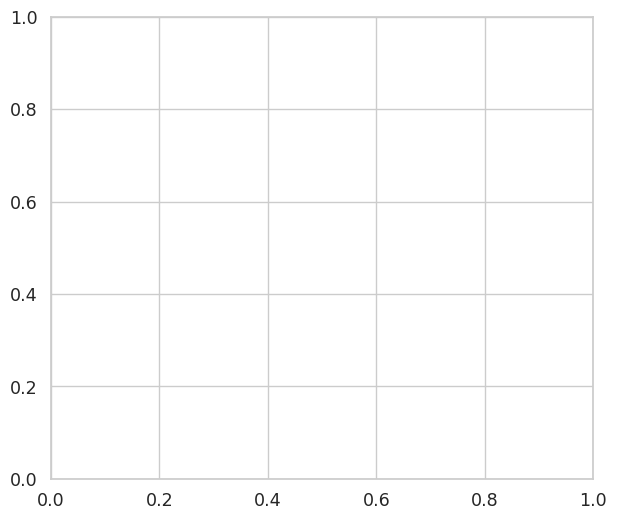

In [63]:
# ── Scatter: per-accent pred_variation — MODEL_A vs MODEL_B ──────────────────
# Points on the diagonal → equal variance; above → B more varied; below → A more varied
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    gmu_var_df[a_name],
    gmu_var_df[b_name],
    c=gmu_var_df["ref_var"],
    cmap="YlOrRd",
    s=gmu_var_df["n"] * 8,
    alpha=0.8,
    edgecolors="#555",
    linewidths=0.4,
    zorder=3,
)

# Diagonal reference line (equal variance)
lim_max = max(gmu_var_df[[a_name, b_name]].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "--", color="#aaaaaa", linewidth=1.2, zorder=1)

# Colorbar for reference variation
cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("Reference variation", fontsize=9)

# Label notable accents (high ref_var or large gap between models)
gmu_var_df["gap"] = (gmu_var_df[b_name] - gmu_var_df[a_name]).abs()
for _, row in gmu_var_df.nlargest(8, "ref_var").iterrows():
    ax.annotate(
        row["accent"].replace("_", " "),
        (row[a_name], row[b_name]),
        fontsize=7.5,
        xytext=(4, 4),
        textcoords="offset points",
        color="#333",
    )

ax.set_xlabel(f"{a_name}  prediction variation", labelpad=8)
ax.set_ylabel(f"{b_name}  prediction variation", labelpad=8)
ax.set_title(
    "Per-accent output variance comparison\n(GMUAccent, dot size ∝ N utts, colour = ref variation)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.grid(color="#e0e0e0", linewidth=0.6)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / "gmu_accent_variance.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'gmu_accent_variance.pdf'}")

In [ ]:
# ── Cell A: Data prep for coverage analysis ──────────────────────────────────
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_train_counts,
    run_coverage_analysis,
    format_coverage_report,
    IPAPACK_YAML,
)
from IPython.display import Markdown, display

# Per-language mean PFER for each model (VoxAngeles)
eval_pfer_a = df_a.groupby("langcode")["pfer"].mean().to_dict()
eval_pfer_b = df_b.groupby("langcode")["pfer"].mean().to_dict()

# Utterance counts per language from training splits
print("Loading training counts...")
train_counts = load_train_counts(IPAPACK_YAML)

Loading training counts...
  Counting train: /work/hdd/bbjs/shared/powsm/s2t1/dump/raw/train_fixed/text

Total: 79 languages, 33099128 utterances


In [ ]:
# ── Cell B: Run coverage-PFER pipeline for both models ───────────────────────
from src.recipe.phone_recognition.local.error_analysis_utils import (
    load_train_counts,
    run_coverage_analysis,
    format_coverage_report,
    IPAPACK_YAML,
)
from IPython.display import Markdown, display

_CSV_A = OUT_DIR / "cache_cov_df_a.csv"
_CSV_B = OUT_DIR / "cache_cov_df_b.csv"
_CSV_CORR = OUT_DIR / "cache_corr_df.csv"

if not FORCE_RECOMPUTE and _CSV_A.exists() and _CSV_B.exists() and _CSV_CORR.exists():
    print("Loading cached coverage DataFrames ...")
    cov_df_a = pd.read_csv(_CSV_A)
    cov_df_b = pd.read_csv(_CSV_B)
    corr_df = pd.read_csv(_CSV_CORR)

    def _res_from_corr(corr_df, model_name):
        rows = corr_df[corr_df.model == model_name].set_index("stratum")

        def _row(s):
            r = rows.loc[s]
            return {
                "n": int(r.N),
                "spearman_rho": r.rho,
                "spearman_p": r.p,
                "bootstrap_ci_95": r.CI_95,
                "permutation_p": r.perm_p if not pd.isna(r.perm_p) else float("nan"),
            }

        by_stratum = {
            s: _row(s) for s in ["seen", "near_unseen", "far_unseen"] if s in rows.index
        }
        return {"overall": _row("overall"), "by_stratum": by_stratum}

    res_a = _res_from_corr(corr_df, a_name)
    res_b = _res_from_corr(corr_df, b_name)
else:
    # Per-language mean PFER for each model (VoxAngeles)
    eval_pfer_a = df_a.groupby("langcode")["pfer"].mean().to_dict()
    eval_pfer_b = df_b.groupby("langcode")["pfer"].mean().to_dict()

    # Utterance counts per language from training splits
    print("Loading training counts...")
    train_counts = load_train_counts(IPAPACK_YAML)

    print(f"Running coverage analysis for {a_name} ...")
    cov_df_a, res_a = run_coverage_analysis(eval_pfer_a, train_counts)

    print(f"\nRunning coverage analysis for {b_name} ...")
    cov_df_b, res_b = run_coverage_analysis(eval_pfer_b, train_counts)

    cov_df_a.to_csv(_CSV_A, index=False)
    cov_df_b.to_csv(_CSV_B, index=False)

    # Build corr_df here so it can be cached alongside the coverage DataFrames
    strata_order = ["overall", "seen", "near_unseen", "far_unseen"]
    corr_rows = []
    for name, res in [(a_name, res_a), (b_name, res_b)]:
        ov = res["overall"]
        corr_rows.append(
            {
                "model": name,
                "stratum": "overall",
                "N": ov["n"],
                "rho": ov["spearman_rho"],
                "p": ov["spearman_p"],
                "CI_95": str(ov["bootstrap_ci_95"]),
                "perm_p": ov.get("permutation_p", float("nan")),
            }
        )
        for stratum, info in res["by_stratum"].items():
            if stratum not in strata_order:
                continue
            if info.get("skipped"):
                corr_rows.append(
                    {
                        "model": name,
                        "stratum": stratum,
                        "N": info["n"],
                        "rho": float("nan"),
                        "p": float("nan"),
                        "CI_95": "—",
                        "perm_p": float("nan"),
                    }
                )
            else:
                corr_rows.append(
                    {
                        "model": name,
                        "stratum": stratum,
                        "N": info["n"],
                        "rho": info["spearman_rho"],
                        "p": info["spearman_p"],
                        "CI_95": str(info.get("bootstrap_ci_95", "—")),
                        "perm_p": info.get("permutation_p", float("nan")),
                    }
                )
    corr_df = pd.DataFrame(corr_rows)
    corr_df.to_csv(_CSV_CORR, index=False)
    print(f"Cached → {_CSV_A}, {_CSV_B}, {_CSV_CORR}")

# Quick summary
for name, res in [(a_name, res_a), (b_name, res_b)]:
    ov = res["overall"]
    print(
        f"\n{name}: rho={ov['spearman_rho']}, p={ov['spearman_p']:.4f}, "
        f"CI={ov['bootstrap_ci_95']}, n={ov['n']}"
    )

# Full Markdown reports
display(Markdown(f"### {a_name}\n" + format_coverage_report(cov_df_a, res_a)))
display(Markdown(f"### {b_name}\n" + format_coverage_report(cov_df_b, res_b)))

Loading cached coverage DataFrames ...

PhoneticXeus: rho=-0.2541, p=0.0961, CI=(np.float64(-0.5115), np.float64(0.0337)), n=44

E-BranchFormer: rho=-0.0878, p=0.5710, CI=(np.float64(-0.3677), np.float64(0.2069)), n=44


KeyError: 'feature_set'

/tmp/ipykernel_1720405/2058105407.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


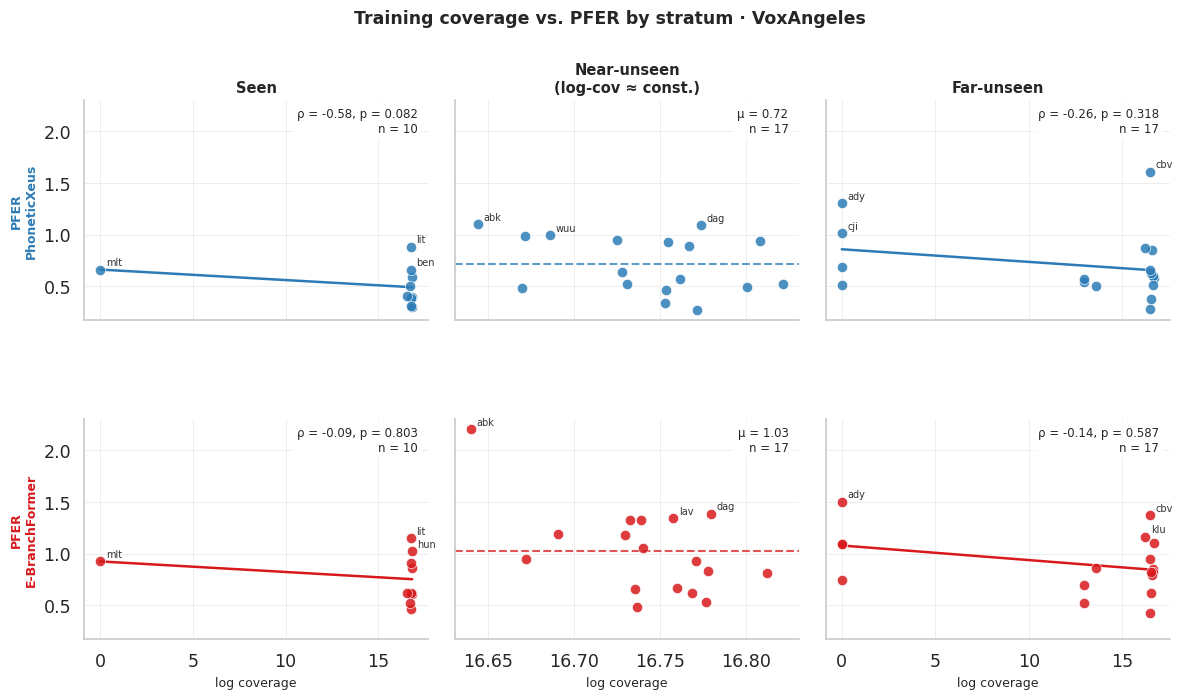

Saved → /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/src/recipe/phone_recognition/local/is26_viz/coverage_pfer.pdf


,model,stratum,N,rho,p,CI_95,perm_p
0,E-BranchFormer,overall,44,-0.088,0.5710,"(np.float64(-0.3677), np.float64(0.2069))",0.5722
1,PhoneticXeus,overall,44,-0.254,0.0961,"(np.float64(-0.5115), np.float64(0.0337))",0.1001
2,E-BranchFormer,seen,10,-0.091,0.8028,"(np.float64(-0.6981), np.float64(0.557))",0.8115
3,PhoneticXeus,seen,10,-0.576,0.0816,"(np.float64(-0.8868), np.float64(0.0314))",0.0893
4,E-BranchFormer,near_unseen,17,-0.201,0.4404,"(np.float64(-0.6462), np.float64(0.3294))",0.4412
5,PhoneticXeus,near_unseen,17,-0.309,0.2279,"(np.float64(-0.7055), np.float64(0.2665))",0.2191
6,E-BranchFormer,far_unseen,17,-0.142,0.5870,"(np.float64(-0.6004), np.float64(0.3695))",0.5811
7,PhoneticXeus,far_unseen,17,-0.258,0.3177,"(np.float64(-0.6455), np.float64(0.2184))",0.3106


In [67]:
# ── Cell C: Visualize coverage-PFER results ──────────────────────────────────
STRATUM_ORDER = ["seen", "near_unseen", "far_unseen"]
STRATUM_TITLES = {
    "seen": "Seen",
    "near_unseen": "Near-unseen\n(log-cov ≈ const.)",
    "far_unseen": "Far-unseen",
}

rng = np.random.default_rng(0)

# ── C1: 2×3 facet grid (row = model, col = stratum) ──────────────────────────
# Separating strata into columns removes the x-range overlap that caused
# 3 crossing regression lines in the old 1×2 layout.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 7),
    sharex="col",
    sharey=True,
    gridspec_kw={"hspace": 0.45, "wspace": 0.08},
)

for row, (name, cov_df, res) in enumerate(
    [(a_name, cov_df_a, res_a), (b_name, cov_df_b, res_b)]
):
    color = PALETTE[name]
    for col, stratum in enumerate(STRATUM_ORDER):
        ax = axes[row, col]
        sub = cov_df[cov_df["stratum"] == stratum].copy()

        # near_unseen: log_coverage ∈ [16.6, 16.8] — add jitter so points
        # don't stack into a vertical line; skip regression (x ≈ const.)
        is_narrow = stratum == "near_unseen"
        if is_narrow:
            sub["x_plot"] = sub["log_coverage"] + rng.uniform(-0.05, 0.05, len(sub))
        else:
            sub["x_plot"] = sub["log_coverage"]

        ax.scatter(
            sub["x_plot"],
            sub["pfer"],
            color=color,
            s=55,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )

        if is_narrow:
            ax.axhline(
                sub["pfer"].mean(),
                color=color,
                linewidth=1.5,
                linestyle="--",
                alpha=0.75,
                zorder=2,
            )
        else:
            sns.regplot(
                data=sub,
                x="x_plot",
                y="pfer",
                ax=ax,
                scatter=False,
                ci=None,
                line_kws=dict(color=color, linewidth=1.8),
            )

        # Label top-3 languages by PFER
        for _, r in sub.nlargest(3, "pfer").iterrows():
            ax.annotate(
                r["lang"],
                (r["x_plot"], r["pfer"]),
                fontsize=7,
                xytext=(4, 3),
                textcoords="offset points",
                color="#333",
            )

        # Stats annotation
        if is_narrow:
            txt = f"μ = {sub['pfer'].mean():.2f}\nn = {len(sub)}"
        else:
            sres = res["by_stratum"].get(stratum, {})
            if sres and not sres.get("skipped"):
                txt = (
                    f"ρ = {sres['spearman_rho']:.2f}, "
                    f"p = {sres['spearman_p']:.3f}\n"
                    f"n = {sres['n']}"
                )
            else:
                txt = f"n = {len(sub)}"
        ax.text(
            0.97,
            0.97,
            txt,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
        )

        # Column title (top row only)
        if row == 0:
            ax.set_title(STRATUM_TITLES[stratum], fontsize=10.5, fontweight="bold")

        # y-label with model name (left column only)
        if col == 0:
            ax.set_ylabel(f"PFER\n{name}", fontsize=9, color=color, fontweight="bold")
        else:
            ax.set_ylabel("")

        # x-label (bottom row only)
        ax.set_xlabel("log coverage" if row == 1 else "", fontsize=9)

        ax.grid(color="#e8e8e8", linewidth=0.5, zorder=0)
        sns.despine(ax=ax)

plt.suptitle(
    "Training coverage vs. PFER by stratum · VoxAngeles",
    fontsize=12.5,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "coverage_pfer.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'coverage_pfer.pdf'}")

# ── C2: Correlation summary table ────────────────────────────────────────────
strata_order = ["overall", "seen", "near_unseen", "far_unseen"]
corr_df_sorted = corr_df.copy()
corr_df_sorted["stratum"] = pd.Categorical(
    corr_df_sorted["stratum"], categories=strata_order, ordered=True
)
corr_df_sorted = corr_df_sorted.sort_values(["stratum", "model"]).reset_index(drop=True)

STRATUM_BG = {
    "overall": "#e8f4f8",
    "seen": "#dbeafe",
    "near_unseen": "#fef3c7",
    "far_unseen": "#fee2e2",
}


def _style_row(row):
    bg = STRATUM_BG.get(row["stratum"], "white")
    bold = "font-weight: bold" if (not pd.isna(row["p"]) and row["p"] < 0.05) else ""
    return [f"background-color: {bg}; {bold}"] * len(row)


display(
    corr_df_sorted.style.apply(_style_row, axis=1)
    .format({"rho": "{:.3f}", "p": "{:.4f}", "perm_p": "{:.4f}"}, na_rep="—")
    .set_caption("Coverage–PFER Spearman correlations by model and stratum")
)

In [68]:
# ── Cell D: Paper-ready LaTeX table + inline text for coverage–PFER results ──
import re


def _fmt_ci(raw_ci_str):
    """Parse '(np.float64(-0.51), np.float64(0.03))' → '[−0.51,\\;0.03]'."""
    nums = re.findall(r"-?\d+\.\d+", str(raw_ci_str))
    lo, hi = float(nums[0]), float(nums[1])
    return f"[{lo:.2f},\\;{hi:.2f}]"


def _fmt_rho(rho, p):
    dagger = r"^\dagger" if p < 0.10 else ""
    return f"${rho:.2f}{dagger}$"


def _fmt_p(p):
    # Format as .XXX (3 decimal places, drop leading zero)
    s = f"{p:.3f}"  # e.g. "0.096"
    s = s.lstrip("0")  # e.g. ".096"
    return f"$p{{=}}{s}$"


STRATUM_LABELS = {
    "overall": r"Overall ($n{=}44$)",
    "seen": r"Seen ($n{=}10$)",
    "far_unseen": r"Far-unseen ($n{=}17$)",
}
STRATA = ["overall", "seen", "far_unseen"]
MODELS = [a_name, b_name]

rows = []
for s in STRATA:
    row = {"stratum": STRATUM_LABELS[s]}
    for m in MODELS:
        r = corr_df[(corr_df.model == m) & (corr_df.stratum == s)].iloc[0]
        rho_str = _fmt_rho(r.rho, r.p)
        ci_str = _fmt_ci(r.CI_95)
        p_str = _fmt_p(r.p)
        row[m] = f"{rho_str} {ci_str}, {p_str}"
    rows.append(row)

# ── Build LaTeX table ─────────────────────────────────────────────────────────
col_a = a_name.replace("-", r"\mbox{-}")  # prevent line break in header
col_b = b_name.replace("-", r"\mbox{-}")

lines = [
    r"\begin{table}[t]",
    r"\centering",
    r"\caption{Spearman correlation between phonologically-weighted training coverage",
    r"         and PFER on VoxAngeles.",
    r"         95\% bootstrap CIs shown in brackets.",
    r"         $^\dagger$\,$p < .10$.",
    r"         Near-unseen languages excluded (coverage $\approx$ constant across",
    r"         all 17 languages due to a shared high-resource neighbour).}",
    r"\label{tab:coverage-pfer}",
    r"\begin{tabular}{lcc}",
    r"\toprule",
    f" & \\textbf{{{col_a}}} & \\textbf{{{col_b}}} \\\\",
    r"\midrule",
]
for row in rows:
    lines.append(f"{row['stratum']:<30} & {row[a_name]:<55} & {row[b_name]} \\\\")
lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
]

latex_src = "\n".join(lines)
print("=" * 72)
print("LATEX TABLE")
print("=" * 72)
print(latex_src)

# ── Inline text ───────────────────────────────────────────────────────────────
ov_a = corr_df[(corr_df.model == a_name) & (corr_df.stratum == "overall")].iloc[0]
seen_a = corr_df[(corr_df.model == a_name) & (corr_df.stratum == "seen")].iloc[0]
ov_b = corr_df[(corr_df.model == b_name) & (corr_df.stratum == "overall")].iloc[0]

inline = (
    f"Table~\\ref{{tab:coverage-pfer}} reports Spearman correlations between "
    f"phonologically-weighted training coverage and PFER across language strata. "
    f"{a_name} shows a consistent negative trend — more coverage associates "
    f"with lower error — reaching marginal significance overall "
    f"($\\rho = {ov_a.rho:.2f}$, $p = {ov_a.p:.3f}$) "
    f"and within seen languages "
    f"($\\rho = {seen_a.rho:.2f}$, $p = {seen_a.p:.3f}$). "
    f"{b_name} exhibits no meaningful relationship "
    f"($\\rho = {ov_b.rho:.2f}$, $p = {ov_b.p:.3f}$), "
    f"suggesting that {a_name}'s multiaccent pretraining better leverages "
    f"phonological proximity to training data."
)

print("\n" + "=" * 72)
print("INLINE TEXT")
print("=" * 72)
print(inline)

LATEX TABLE
\begin{table}[t]
\centering
\caption{Spearman correlation between phonologically-weighted training coverage
         and PFER on VoxAngeles.
         95\% bootstrap CIs shown in brackets.
         $^\dagger$\,$p < .10$.
         Near-unseen languages excluded (coverage $\approx$ constant across
         all 17 languages due to a shared high-resource neighbour).}
\label{tab:coverage-pfer}
\begin{tabular}{lcc}
\toprule
 & \textbf{PhoneticXeus} & \textbf{E\mbox{-}BranchFormer} \\
\midrule
Overall ($n{=}44$)             & $-0.25^\dagger$ [-0.51,\;0.03], $p{=}.096$              & $-0.09$ [-0.37,\;0.21], $p{=}.571$ \\
Seen ($n{=}10$)                & $-0.58^\dagger$ [-0.89,\;0.03], $p{=}.082$              & $-0.09$ [-0.70,\;0.56], $p{=}.803$ \\
Far-unseen ($n{=}17$)          & $-0.26$ [-0.65,\;0.22], $p{=}.318$                      & $-0.14$ [-0.60,\;0.37], $p{=}.587$ \\
\bottomrule
\end{tabular}
\end{table}

INLINE TEXT
Table~\ref{tab:coverage-pfer} reports Spearman correlations